In [3]:
import os
import re
import requests
import arxiv as arxiv_lib
from dotenv import load_dotenv
from typing import List
from pydantic import BaseModel
from langchain.tools import tool
from langchain_core.tools import Tool
from langchain.chat_models import init_chat_model
from langchain_openai import OpenAIEmbeddings
from langchain_ollama import OllamaEmbeddings
from langchain_core.documents import Document
from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import TextLoader
from langchain_community.document_loaders.youtube import YoutubeLoader
from langchain_community.document_loaders import ArxivLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import StateGraph, END
from langfuse.langchain import CallbackHandler

load_dotenv()

langfuse_trace = CallbackHandler()

In [4]:
openai_llm = init_chat_model("openai:gpt-4o-mini")
ollama_llm = init_chat_model(
    model="granite4",
    model_provider="ollama"
)

In [5]:
def load_text_retriever(file_path):
    docs = TextLoader(file_path, encoding="utf-8").load()
    splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
    chunks = splitter.split_documents(docs)
    # vs = FAISS.from_documents(chunks, OpenAIEmbeddings())
    vs = FAISS.from_documents(chunks, OllamaEmbeddings(
        model="nomic-embed-text"
    ))
    return vs.as_retriever()

In [6]:
def load_youtube_retriever():
    # Mocked YouTube transcript text
    content = """
    This video explains how agentic AI systems rely on feedback loops, memory, and tool use.
    It compares them to traditional pipeline-based LLMs. Temporal reasoning and autonomous tasking are emphasized.
    """
    doc = Document(page_content=content, metadata={"source": "youtube"})
    vectorstore = FAISS.from_documents([doc], OllamaEmbeddings(
        model="nomic-embed-text"
    ))
    return vectorstore.as_retriever()

In [7]:
text_retriever = load_text_retriever("internal_docs.txt")
youtube_retriever = load_youtube_retriever()

In [8]:
### state
class MultiSourceRAGState(BaseModel):
    question: str
    text_docs: List[Document] = []
    yt_docs: List[Document] = []
    wiki_context: str = ""
    arxiv_context: str = ""
    final_answer: str = ""

In [9]:
# Cấu hình tra cứu arxiv


ARXIV_TOP_K = 2          # số kết quả trả về
ARXIV_MAX_CHARS = 500    # độ dài tối đa của summary mỗi bài

# Regex nhận diện arXiv ID (vd: 1706.03762, hep-th/9901001) để tra theo id thay vì full-text
_ARXIV_ID = re.compile(r"\d{4}\.\d{4,5}(v\d+)?$|[a-z\-]+(\.[A-Z]{2})?/\d{7}(v\d+)?$")
_arxiv_client = arxiv_lib.Client()


def arxiv_search(query: str) -> str:
    """
    Search arXiv for academic and scientific research papers.

    Best used for research topics, paper summaries, literature reviews,
    machine learning, AI, computer science, mathematics, and physics.

    Input: a research query, paper title, keyword, or arXiv ID.
    Output: publication date, title, authors, and paper abstract.
    """
    if _ARXIV_ID.match(query.strip()):
        search = arxiv_lib.Search(id_list=query.split(), max_results=ARXIV_TOP_K)
    else:
        search = arxiv_lib.Search(
            query=query[:300],
            max_results=ARXIV_TOP_K,
            sort_by=arxiv_lib.SortCriterion.Relevance,
        )
    docs = []
    for r in _arxiv_client.results(search):
        authors = ", ".join(a.name for a in r.authors)
        docs.append(
            f"Published: {r.published.date()}\n"
            f"Title: {r.title}\n"
            f"Authors: {authors}\n"
            f"Summary: {r.summary[:ARXIV_MAX_CHARS]}"
        )
    return "\n\n".join(docs) if docs else "No good arXiv results found."


In [10]:
# Cấu hình tra cứu Wikipedia

WIKI_TOP_K = 1           # số trang trả về
WIKI_MAX_CHARS = 500     # độ dài tối đa của summary mỗi trang
WIKI_LANG = "en"         # ngôn ngữ (vd: "en", "vi")

_WIKI_API = f"https://{WIKI_LANG}.wikipedia.org/w/api.php"
# Wikimedia yêu cầu User-Agent mô tả rõ ứng dụng; thiếu nó dễ bị chặn -> response rỗng -> JSONDecodeError
_WIKI_HEADERS = {"User-Agent": "ultimate-rag-bootcamp/1.0 (educational project)"}


def wikipedia_search(query: str) -> str:
    """
    Search Wikipedia for factual information and encyclopedia-style summaries.

    Best used for general knowledge, people, places, organizations,
    historical events, scientific concepts, and topic overviews.

    Input: a search query.
    Output: the most relevant Wikipedia page title and summary.
    """

    # 1) Tìm các trang khớp với truy vấn
    resp = requests.get(
        _WIKI_API,
        params={"action": "query", "list": "search", "srsearch": query,
                "srlimit": WIKI_TOP_K, "format": "json"},
        headers=_WIKI_HEADERS, timeout=10,
    )
    resp.raise_for_status()
    hits = resp.json().get("query", {}).get("search", [])
    if not hits:
        return "No good Wikipedia Search Result was found"

    # 2) Lấy phần tóm tắt (plain text) cho từng trang
    docs = []
    for hit in hits:
        title = hit["title"]
        page = requests.get(
            _WIKI_API,
            params={"action": "query", "prop": "extracts", "explaintext": 1,
                    "titles": title, "redirects": 1, "format": "json"},
            headers=_WIKI_HEADERS, timeout=10,
        )
        page.raise_for_status()
        pages = page.json().get("query", {}).get("pages", {})
        extract = next(iter(pages.values()), {}).get("extract", "")
        docs.append(f"Page: {title}\nSummary: {extract[:WIKI_MAX_CHARS]}")
    return "\n\n".join(docs)


In [11]:
### Retrieval Nodes
def retrieve_text(state: MultiSourceRAGState) -> MultiSourceRAGState:
    docs = text_retriever.invoke(state.question, config={'callbacks': [langfuse_trace]})
    return state.model_copy(update={"text_docs": docs})

def retrieve_yt(state: MultiSourceRAGState) -> MultiSourceRAGState:
    docs = youtube_retriever.invoke(state.question, config={'callbacks': [langfuse_trace]})
    return state.model_copy(update={"yt_docs": docs})

def retrieve_wikipedia(state: MultiSourceRAGState) -> MultiSourceRAGState:
    result = wikipedia_search(state.question)
    return state.model_copy(update={"wiki_context": result})

def retrieve_arxiv(state: MultiSourceRAGState) -> MultiSourceRAGState:
    result = arxiv_search(state.question)
    return state.model_copy(update={"arxiv_context": result})

In [12]:
## synthesize
def synthesize_answer(state: MultiSourceRAGState) -> MultiSourceRAGState:
    
    context = ""

    context += "\n\n[Internal Docs]\n" + "\n".join([doc.page_content for doc in state.text_docs])
    context += "\n\n[YouTube Transcript]\n" + "\n".join([doc.page_content for doc in state.yt_docs])
    context += "\n\n[Wikipedia]\n" + state.wiki_context
    context += "\n\n[ArXiv]\n" + state.arxiv_context

    prompt = f"""You have retrieved relevant context from multiple sources. Now synthesize a complete and coherent answer.

Question: {state.question}

Context:
{context}

Final Answer:"""

    answer = ollama_llm.invoke(prompt, config={'callbacks': [langfuse_trace]}).content.strip()
    return state.model_copy(update={"final_answer": answer})

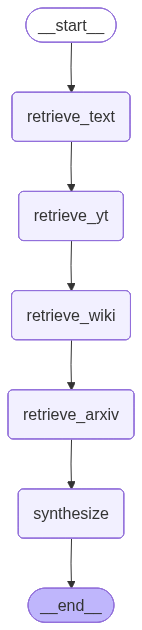

In [13]:
builder = StateGraph(MultiSourceRAGState)

builder.add_node("retrieve_text", retrieve_text)
builder.add_node("retrieve_yt", retrieve_yt)
builder.add_node("retrieve_wiki", retrieve_wikipedia)
builder.add_node("retrieve_arxiv", retrieve_arxiv)
builder.add_node("synthesize", synthesize_answer)

builder.set_entry_point("retrieve_text")
builder.add_edge("retrieve_text", "retrieve_yt")
builder.add_edge("retrieve_yt", "retrieve_wiki")
builder.add_edge("retrieve_wiki", "retrieve_arxiv")
builder.add_edge("retrieve_arxiv", "synthesize")
builder.add_edge("synthesize", END)

graph = builder.compile()
graph

In [14]:
question = "What are transformer agents and how are they evolving in recent research?"
state = MultiSourceRAGState(question=question)
result = graph.invoke(state, config={'callbacks': [langfuse_trace]})

print("✅ Final Answer:\n")
print(result["final_answer"])


HTTPError: Page request resulted in HTTP 503 (https://export.arxiv.org/api/query?search_query=What+are+transformer+agents+and+how+are+they+evolving+in+recent+research%3F&id_list=&sortBy=relevance&sortOrder=descending&start=0&max_results=100)